# Part 1 - Determinants of Mortgage Default in the CMLTI 2006-NC2 Pool

We analyze loan-level data from the CMLTI 2006-NC2 mortgage pool, originated just before the 2008 US financial crisis. We keep first-lien loans, build one observation per loan, and flag a loan as defaulted if it ever reaches a default-type delinquency status. After merging local house price appreciation (HPA) data by zip code, we estimate a logistic regression of default on borrower and loan characteristics (FICO, LTV, DTI, rate, documentation, loan purpose, occupancy, balloon feature, HPA) and check multicollinearity and the DTI distribution.

## 1.1 Imports and data loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
# Note: The dataset 'CMLTI 2006-NC2 Loan-Level Panel Data.xlsx' is proprietary 
# academic/financial data and is therefore not included in this public repository.

file_name = 'CMLTI 2006-NC2 Loan-Level Panel Data.xlsx'

df_panel = pd.read_excel(file_name, sheet_name='loan_level_panel')


## 1.2 Data preparation: first-lien loans, dummy variables, one row per loan

In [3]:
df_first = df_panel[df_panel['lien_type'] == 1].copy()

#We create dummy variables for the regression analysis 
#Create default status : 1 if the loan is in default, 0 otherwise
status_defaut = ['9', 'F', 'L', 'R', 'B']
df_first['default'] = df_first['deliquency_status'].astype(str).isin(status_defaut).astype(int)

#Create a dummy variable for documentation level : 1 if full documentation, 0 if low documentation
df_first['doc'] = df_first['doc_type_summary'].astype(str).isin(['FU']).astype(int)

#Create a dummy variable if cashout refinancing loan : 1 if cashout, 0 otherwise
df_first['cashout'] = df_first['loanpurp'].astype(str).isin(['Cash-out Refinance']).astype(int)

#Create a dummy variable for balloon loans : 1 if balloon, 0 otherwise
df_first['balloon'] = df_first['balloon'].astype(str).isin(['Y']).astype(int)

#Create a dummy variable for missing debt-to-income ratio : 1 if missing, 0 otherwise
df_first['dti_missing'] = df_first['dti'].isna().astype(int)


#Create a dummy variable for investor : 1 if the borrower is an investor, 0 otherwise
df_first['Investor'] = df_first['ownocc'].astype(str).isin(['Investor']).astype(int)

#Create a dummy variable for secondary residency : 1 if the residency status is secondary, 0 otherwise
df_first['Secondary'] = df_first['ownocc'].astype(str).isin(['Secondary']).astype(int)




#We restrict to one observation per loan, and only keep the relevant variables
df_loans = df_first.groupby('loanno').agg({
    'default': 'max',           
    'zip': 'first',                 
    'fico': 'first',              
    'ltvorig': 'first',             
    'dti': 'first',     
    'rate': 'first', 
    'orig_bal_r': 'first',
    'doc' : 'first',
    'cashout' : 'first',
    'balloon' : 'first',
    'dti_missing' : 'first',
    'Investor' : 'first',
    'salesprice': 'first',
    'Secondary' : 'first'
}).reset_index()

default_rate = df_loans['default'].mean()
print(f"Default rate calculated : {default_rate:.1%}")



Default rate calculated : 62.4%


## 1.3 Merge with house price appreciation (HPA) data

In [4]:
#We merge the data with the HPA data
hpa = pd.read_csv('HPA.csv')
df_merged = pd.merge(df_loans, hpa,on='zip', how='left')


## 1.4 Logistic regression of default

In [ ]:
#Logistic regression

formula = """default ~ fico + ltvorig + dti + cashout + balloon + Investor + rate +
         HPA2006_00 + HPA2010_06 + orig_bal_r + doc + Secondary"""



#The model doesn't converge if I add dti_missing, and it is not stat. signif.
model = smf.logit(formula, data=df_merged).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.593400
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                 3660
Model:                          Logit   Df Residuals:                     3647
Method:                           MLE   Df Model:                           12
Date:                Wed, 15 Apr 2026   Pseudo R-squ.:                  0.1055
Time:                        09:27:07   Log-Likelihood:                -2171.8
converged:                       True   LL-Null:                       -2428.1
Covariance Type:            nonrobust   LLR p-value:                4.752e-102
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.9246      0.874      2.203      0.028       0.212       3.637
fico          -0.0065      0.

## 1.5 Multicollinearity check: correlation matrix

Text(0.5, 1.0, 'Correlation Matrix Heatmap')

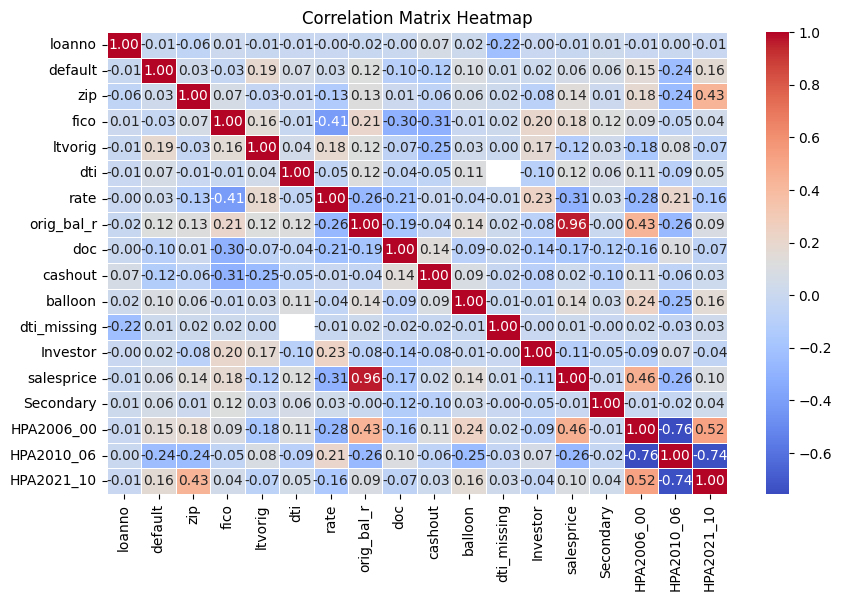

In [ ]:
#We can also look at the correlation matrix to check for multicollinearity issues
correlation_matrix = df_merged.corr()

plt.figure(figsize=(10, 6))

# Create a heatmap for the correlation matrix
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Heatmap')

## 1.6 Distribution of the debt-to-income ratio (DTI)

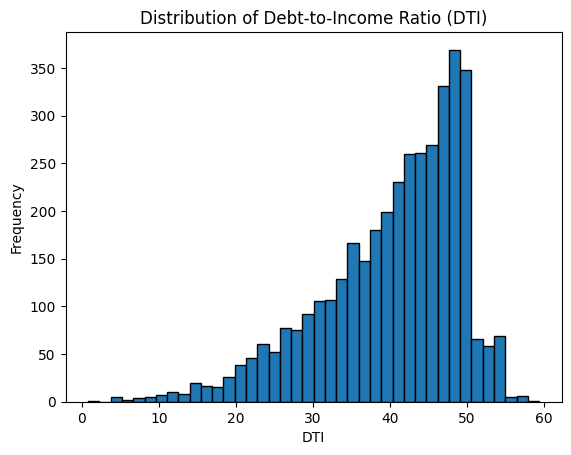

In [7]:
#We also plot an histogram of the dti variable to see its distribution
#We can see that there is a threshold at ~50% to obtain a loan
plt.hist(df_merged['dti'], bins=40, edgecolor='k')
plt.title('Distribution of Debt-to-Income Ratio (DTI)')
plt.xlabel('DTI')
plt.ylabel('Frequency')
plt.show()

# Part 2 - Balloon Loans and Default

We measure the share of balloon loans in the sample and compare the default rate of balloon loans with that of non-balloon loans.

In [8]:
#Compute the proportion of balloon loans in the sample
num_balloon = df_merged['balloon'].mean()
print(f"Proportion of balloon loans: {num_balloon:.2%}")

#Compute default rates for balloon and non-balloon loans
default_balloon = df_merged[df_merged['balloon'] == 1]['default'].mean()
print(f"Default rate for balloon loans: {default_balloon:.2%}")

default_no_balloon = df_merged[df_merged['balloon'] == 0]['default'].mean()
print(f"Default rate for non-balloon loans: {default_no_balloon:.2%}")

Proportion of balloon loans: 41.78%
Default rate for balloon loans: 67.95%
Default rate for non-balloon loans: 58.39%


# Part 3 - House Price Appreciation Before the Crisis

We look at the distribution of HPA2006_00, the house price appreciation by zip code, to see how local housing markets evolved over the 2000-2006 boom.

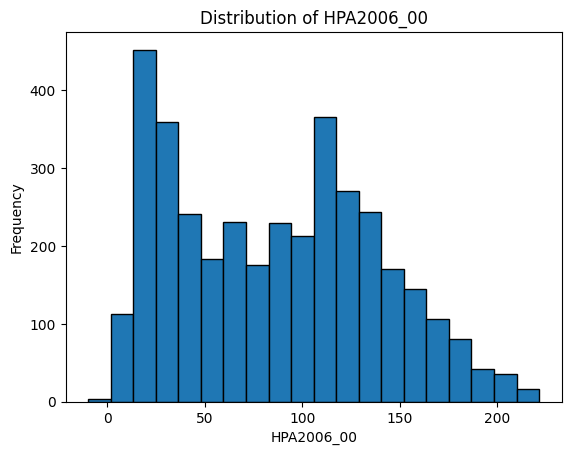

In [5]:
#Histogram of HPA2006_00
plt.hist(df_merged['HPA2006_00'], bins=20, edgecolor='k')
plt.title('Distribution of HPA2006_00')
plt.xlabel('HPA2006_00')
plt.ylabel('Frequency')
plt.show()

# Part 4 - Loan Modifications and Re-Default

Using the monthly loan panel, we count how many loans were modified (all loans, then first-lien only), look at their delinquency status just before modification, and study the changes in interest rate and balance at modification. We finally compute the re-default rate: the share of modified loans that default again after the modification.

## 4.1 Number of modified loans

In [ ]:
#Number of loans modified at least once
df_panel['modified_bool'] = df_panel['modified'].astype(str).isin(['L','P']).astype(int)
df_modified = df_panel.groupby('loanno').agg({'modified_bool': 'max'})
num_modified = df_modified['modified_bool'].sum()
print(f"Number of loans modified at least once: {num_modified}")


#Now only for first lien loans
df_first_mod = df_panel[df_panel['lien_type'] == 1].copy()
df_first_mod['modified_bool'] = df_first_mod['modified'].astype(str).isin(['L','P']).astype(int)
df_modified = df_first_mod.groupby('loanno').agg({'modified_bool': 'max'})
num_modified_first = df_modified['modified_bool'].sum()
print(f"Number of first lien loans modified at least once: {num_modified_first}")


Number of loans modified at least once: 729
Number of first lien loans modified at least once: 703


## 4.2 Delinquency status before modification

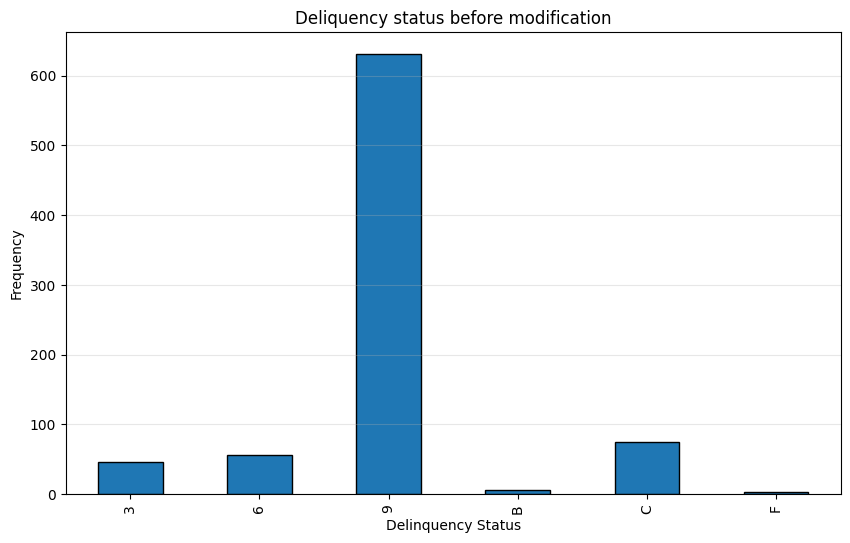

status_before
3     46
6     56
9    631
B      5
C     74
F      3
Name: count, dtype: int64


In [11]:
#Sort in chronological order and by loan number
df_panel = df_panel.sort_values(['loanno', 'activity_date'])

#Take the status of the month before modification
df_panel['status_before'] = df_panel.groupby('loanno')['deliquency_status'].shift(1)
df_pre_mod = df_panel[df_panel['modified_bool'] == 1].copy()
df_pre_mod['status_before'] = df_pre_mod['status_before'].astype(str)

#Histogram of deliquency status for modified loans
plt.figure(figsize=(10,6))

#Find the frequencies of each deliquency status before modification and sort them 
counts = df_pre_mod['status_before'].value_counts().sort_index()
counts.plot(kind='bar', edgecolor='k')

plt.title('Deliquency status before modification')
plt.xlabel('Delinquency Status')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()
print(counts)

## 4.3 Changes in interest rate and balance at modification

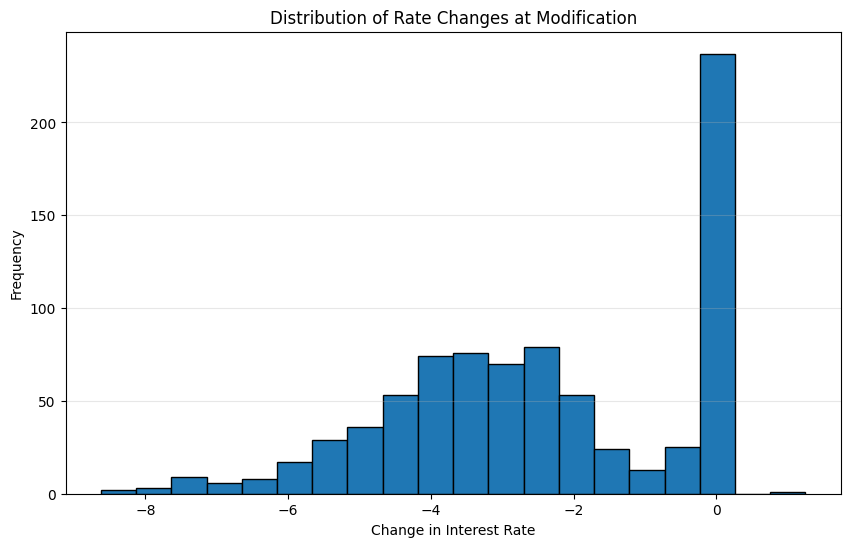

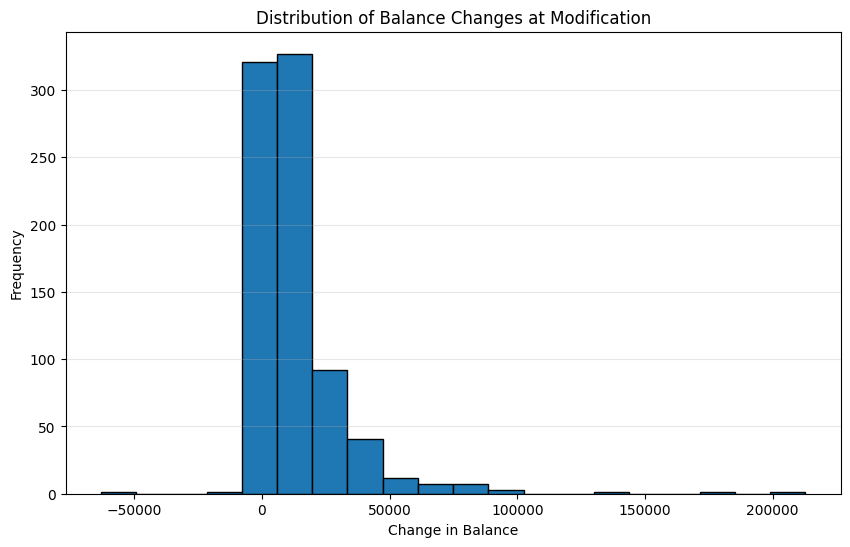

In [ ]:
#Now we look at the distribution of changes in interest rate and balance 

#Sort in chronological order and by loan number
df_panel = df_panel.sort_values(['loanno', 'activity_date'])

#Create lagged column to compare
df_panel['prev_rate'] = df_panel.groupby('loanno')['current_rate'].shift(1)
df_panel['prev_bal'] = df_panel.groupby('loanno')['current_balance'].shift(1)

#Compute the changes in interest rate and balance
df_panel['rate_change'] = df_panel['current_rate'] - df_panel['prev_rate']
df_panel['bal_change'] = df_panel['current_balance'] - df_panel['prev_bal']

#Keep only the rows where a modification has just occurred 
mod_events = df_panel[df_panel['modified_bool'] == 1]

plt.figure(figsize=(10,6))
plt.hist(mod_events['rate_change'], bins=20, edgecolor='k')
plt.title('Distribution of Rate Changes at Modification')
plt.xlabel('Change in Interest Rate')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(10,6))
plt.hist(mod_events['bal_change'], bins=20, edgecolor='k')
plt.title('Distribution of Balance Changes at Modification')
plt.xlabel('Change in Balance')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

## 4.4 Re-default rate after modification

In [13]:

#Find percentage of modified loans that went into default again after modification
df_panel = df_panel.sort_values(['loanno', 'activity_date'])

#Identify the first month where there is a modfication
df_panel['is_mod'] = df_panel['modified'].astype(str).isin(['L', 'P']).astype(int)

#Identify modified loans
df_mod = df_panel[df_panel.groupby('loanno')['is_mod'].transform('max') == 1].copy()

#Create a column with the deliquency status right after the modification (else we will count the status of the month of modification, which is not relevant)
df_mod['strictly_after_mod'] = df_mod.groupby('loanno')['is_mod'].shift(1).fillna(0)
df_mod['strictly_after_mod'] = df_mod.groupby('loanno')['strictly_after_mod'].cummax()

#Define default on this follow-up period
df_mod['failed_after'] = (df_mod['strictly_after_mod'] == 1) & (df_mod['deliquency_status'].astype(str).isin(status_defaut))

#Calculate the re-default rate
re_default_rate = df_mod.groupby('loanno')['failed_after'].max().mean()

print(f"Re-default rate : {re_default_rate:.1%}")

Re-default rate : 44.9%


# Part 5 - Total Losses of the Pool

We take the final cumulative loss of each loan and sum them to obtain the total loss borne by the mortgage pool.

In [14]:
#Question 5
#We take the last value of cumulative loss for each loan and then we sum
df_loss = df_panel.groupby('loanno').agg({'cumulative_loss': 'last'})
print(f"The total loss is : {df_loss['cumulative_loss'].sum():.2f}$")

The total loss is : 224709049.84$
